In [5]:
# FocusGuard — AI Student Productivity Prediction

### Machine Learning Project

**Goal:** Predict student productivity using study habits,
sleep, digital distraction, and lifestyle-related factors.

### Project Pipeline
1. Data Collection
2. Data Understanding
3. Data Cleaning
4. Exploratory Data Analysis
5. Feature Engineering
6. Machine Learning
7. Model Evaluation
8. Explainable AI
9. What-If Analysis
10. Streamlit Dashboard

SyntaxError: invalid syntax (770371925.py, line 5)

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("student_productivity.csv")

df.head()

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level
0,1,6.9,3.8,8.7,2.8,1.8,2.99,Moderate
1,2,5.3,3.5,8.0,4.2,3.0,2.75,Low
2,3,5.1,3.9,9.2,1.2,4.6,2.67,Low
3,4,6.5,2.1,7.2,1.7,6.5,2.88,Moderate
4,5,8.1,0.6,6.5,2.2,6.6,3.51,High


In [8]:
df.columns

Index(['Student_ID', 'Study_Hours_Per_Day', 'Extracurricular_Hours_Per_Day',
       'Sleep_Hours_Per_Day', 'Social_Hours_Per_Day',
       'Physical_Activity_Hours_Per_Day', 'GPA', 'Stress_Level'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Student_ID                       2000 non-null   int64  
 1   Study_Hours_Per_Day              2000 non-null   float64
 2   Extracurricular_Hours_Per_Day    2000 non-null   float64
 3   Sleep_Hours_Per_Day              2000 non-null   float64
 4   Social_Hours_Per_Day             2000 non-null   float64
 5   Physical_Activity_Hours_Per_Day  2000 non-null   float64
 6   GPA                              2000 non-null   float64
 7   Stress_Level                     2000 non-null   object 
dtypes: float64(6), int64(1), object(1)
memory usage: 125.1+ KB


In [10]:
df.isnull().sum()

Student_ID                         0
Study_Hours_Per_Day                0
Extracurricular_Hours_Per_Day      0
Sleep_Hours_Per_Day                0
Social_Hours_Per_Day               0
Physical_Activity_Hours_Per_Day    0
GPA                                0
Stress_Level                       0
dtype: int64

In [11]:
df.describe()

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,1000.500000,7.475800,1.990100,7.501250,2.704550,4.32830,3.115960
std,577.494589,1.423888,1.155855,1.460949,1.688514,2.51411,0.298674
min,1.000000,5.000000,0.000000,5.000000,0.000000,0.00000,2.240000
25%,500.750000,6.300000,1.000000,6.200000,1.200000,2.40000,2.900000
50%,1000.500000,7.400000,2.000000,7.500000,2.600000,4.10000,3.110000
75%,1500.250000,8.700000,3.000000,8.800000,4.100000,6.10000,3.330000
max,2000.000000,10.000000,4.000000,10.000000,6.000000,13.00000,4.000000


In [12]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [13]:
print("Dataset Shape:", df.shape)
print("\nColumns:")
for column in df.columns:
    print("-", column)

Dataset Shape: (2000, 8)

Columns:
- Student_ID
- Study_Hours_Per_Day
- Extracurricular_Hours_Per_Day
- Sleep_Hours_Per_Day
- Social_Hours_Per_Day
- Physical_Activity_Hours_Per_Day
- GPA
- Stress_Level


In [14]:
df.tail()

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level
1995,1996,6.5,0.2,7.4,2.1,7.8,3.32,Moderate
1996,1997,6.3,2.8,8.8,1.5,4.6,2.65,Moderate
1997,1998,6.2,0.0,6.2,0.8,10.8,3.14,Moderate
1998,1999,8.1,0.7,7.6,3.5,4.1,3.04,High
1999,2000,9.0,1.7,7.3,3.1,2.9,3.58,High


In [15]:
df.dtypes

Student_ID                           int64
Study_Hours_Per_Day                float64
Extracurricular_Hours_Per_Day      float64
Sleep_Hours_Per_Day                float64
Social_Hours_Per_Day               float64
Physical_Activity_Hours_Per_Day    float64
GPA                                float64
Stress_Level                        object
dtype: object

In [16]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print(missing_percentage)

Student_ID                         0.0
Study_Hours_Per_Day                0.0
Extracurricular_Hours_Per_Day      0.0
Sleep_Hours_Per_Day                0.0
Social_Hours_Per_Day               0.0
Physical_Activity_Hours_Per_Day    0.0
GPA                                0.0
Stress_Level                       0.0
dtype: float64


In [17]:
summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df)) * 100,
    "Unique Values": df.nunique()
})

summary

,Data Type,Missing Values,Missing %,Unique Values
Student_ID,int64,0,0.0,2000
Study_Hours_Per_Day,float64,0,0.0,51
Extracurricular_Hours_Per_Day,float64,0,0.0,41
Sleep_Hours_Per_Day,float64,0,0.0,51
Social_Hours_Per_Day,float64,0,0.0,61
Physical_Activity_Hours_Per_Day,float64,0,0.0,118
GPA,float64,0,0.0,158
Stress_Level,object,0,0.0,3


In [18]:
numerical_columns = df.select_dtypes(include=np.number).columns

print("Numerical Columns:")
print(numerical_columns)

Numerical Columns:
Index(['Student_ID', 'Study_Hours_Per_Day', 'Extracurricular_Hours_Per_Day',
       'Sleep_Hours_Per_Day', 'Social_Hours_Per_Day',
       'Physical_Activity_Hours_Per_Day', 'GPA'],
      dtype='object')


In [19]:
categorical_columns = df.select_dtypes(include="object").columns

print("Categorical Columns:")
print(categorical_columns)

Categorical Columns:
Index(['Stress_Level'], dtype='object')


In [20]:
print("Number of numerical columns:", len(numerical_columns))
print("Number of categorical columns:", len(categorical_columns))

Number of numerical columns: 7
Number of categorical columns: 1


In [21]:
df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Student_ID,2000.0,1000.50000,577.494589,1.00,500.75,1000.50,1500.25,2000.0
Study_Hours_Per_Day,2000.0,7.47580,1.423888,5.00,6.30,7.40,8.70,10.0
Extracurricular_Hours_Per_Day,2000.0,1.99010,1.155855,0.00,1.00,2.00,3.00,4.0
Sleep_Hours_Per_Day,2000.0,7.50125,1.460949,5.00,6.20,7.50,8.80,10.0
Social_Hours_Per_Day,2000.0,2.70455,1.688514,0.00,1.20,2.60,4.10,6.0
Physical_Activity_Hours_Per_Day,2000.0,4.32830,2.514110,0.00,2.40,4.10,6.10,13.0
GPA,2000.0,3.11596,0.298674,2.24,2.90,3.11,3.33,4.0


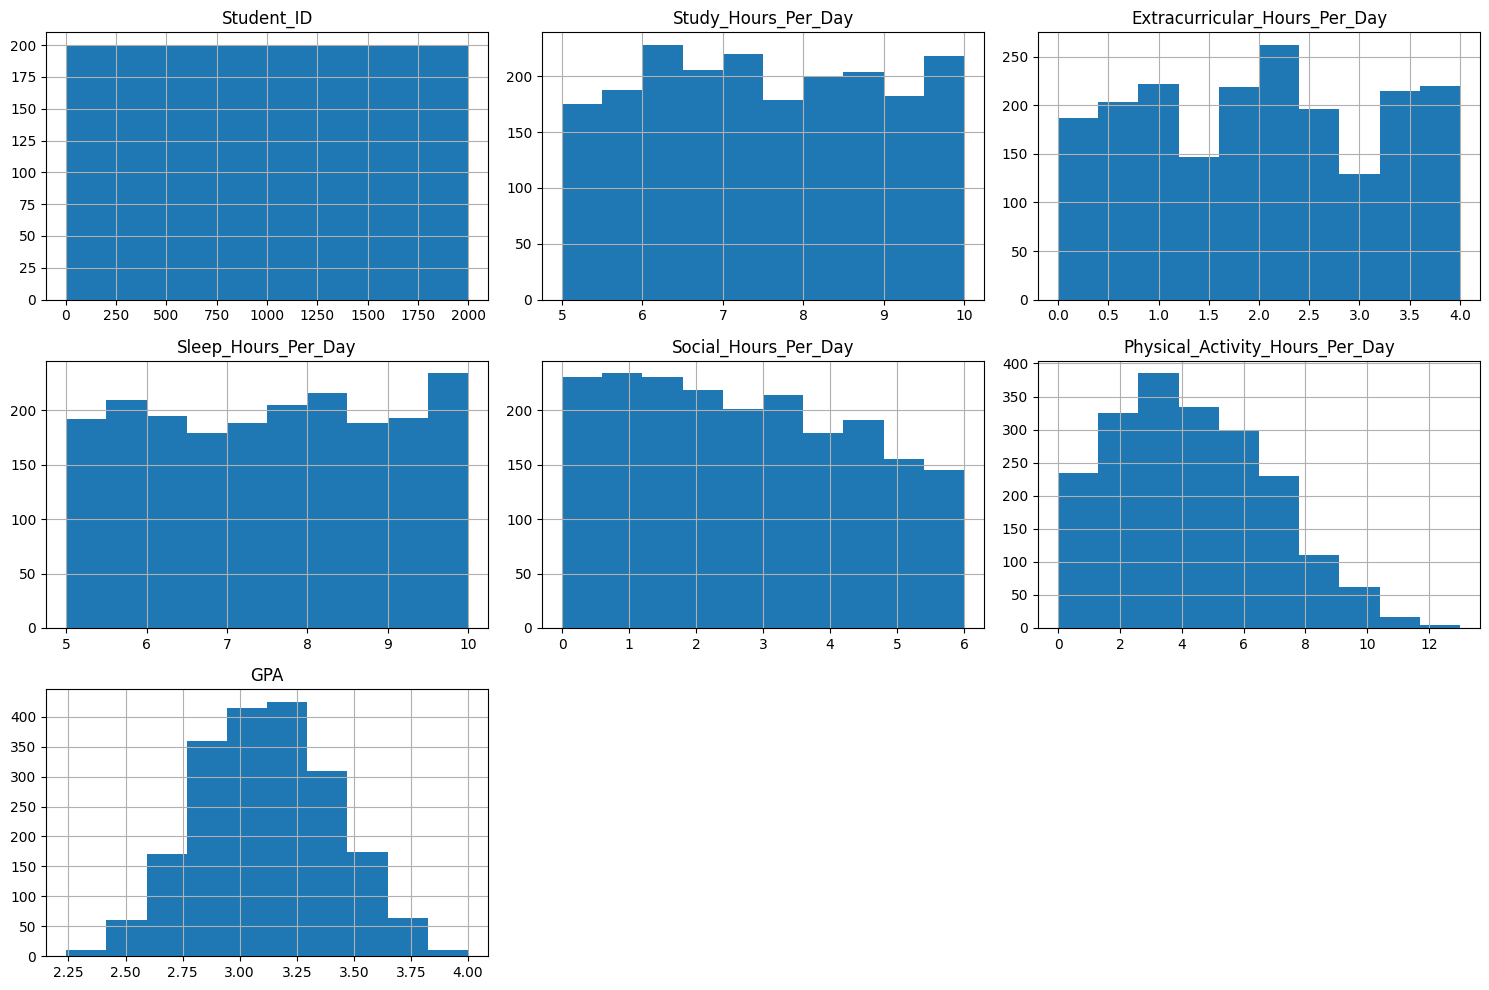

In [22]:
df[numerical_columns].hist(figsize=(15, 10))

plt.tight_layout()
plt.show()

In [23]:
correlation = df[numerical_columns].corr()

correlation

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA
Student_ID,1.000000,0.014034,-0.018424,-0.001411,-0.004363,0.004273,0.005416
Study_Hours_Per_Day,0.014034,1.000000,-0.002629,0.026717,-0.137820,-0.488113,0.734468
Extracurricular_Hours_Per_Day,-0.018424,-0.002629,1.000000,0.008844,-0.139081,-0.369989,-0.032174
Sleep_Hours_Per_Day,-0.001411,0.026717,0.008844,1.000000,-0.193556,-0.470302,-0.004278
Social_Hours_Per_Day,-0.004363,-0.137820,-0.139081,-0.193556,1.000000,-0.417142,-0.085677
Physical_Activity_Hours_Per_Day,0.004273,-0.488113,-0.369989,-0.470302,-0.417142,1.000000,-0.341152
GPA,0.005416,0.734468,-0.032174,-0.004278,-0.085677,-0.341152,1.000000


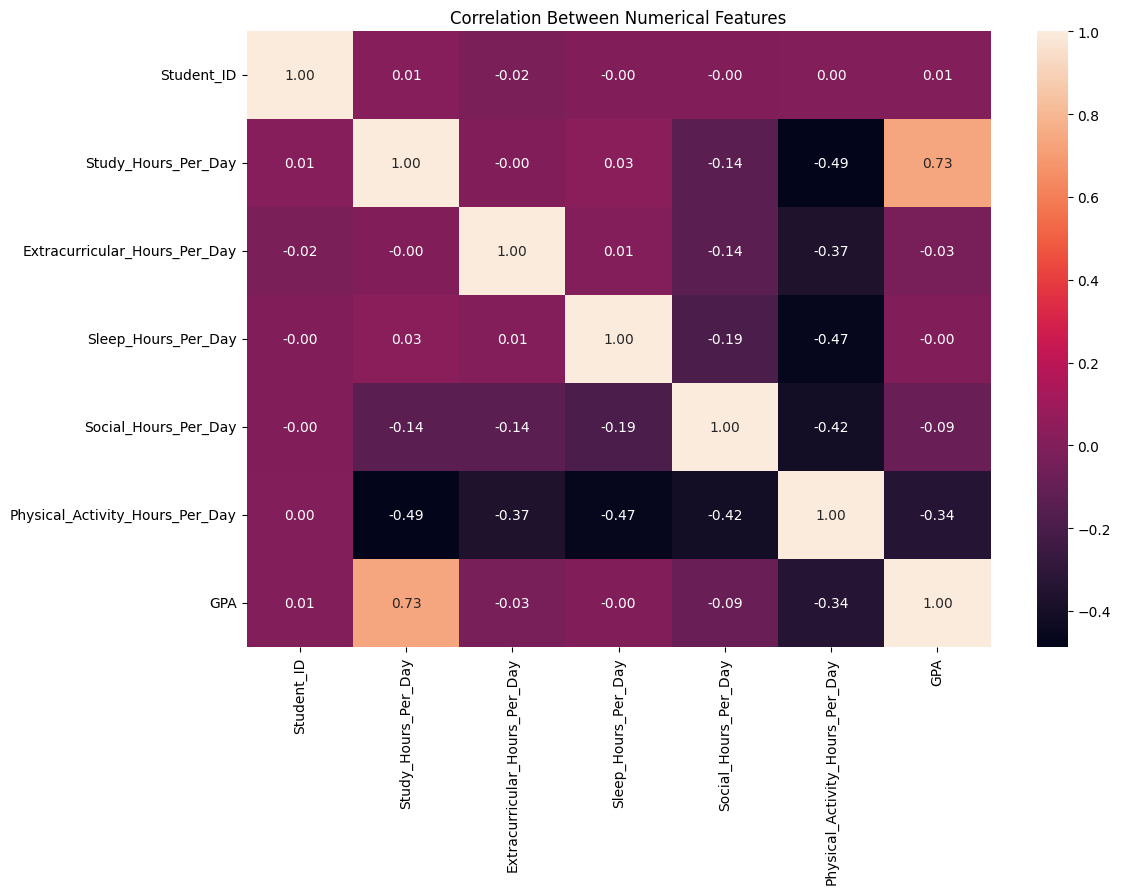

In [24]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Between Numerical Features")
plt.show()

In [25]:
for column in categorical_columns:
    print("\nColumn:", column)
    print(df[column].value_counts())


Column: Stress_Level
Stress_Level
High        1029
Moderate     674
Low          297
Name: count, dtype: int64


In [26]:
print("========== FOCUSGUARD DATASET REPORT ==========")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nTotal Missing Values:", df.isnull().sum().sum())

print("\nNumerical Columns:", len(numerical_columns))
print("Categorical Columns:", len(categorical_columns))

print("\n========== COLUMN NAMES ==========")
for column in df.columns:
    print(column)

========== FOCUSGUARD DATASET REPORT ==========
Rows: 2000
Columns: 8

Duplicate Rows: 0

Total Missing Values: 0

Numerical Columns: 7
Categorical Columns: 1

========== COLUMN NAMES ==========
Student_ID
Study_Hours_Per_Day
Extracurricular_Hours_Per_Day
Sleep_Hours_Per_Day
Social_Hours_Per_Day
Physical_Activity_Hours_Per_Day
GPA
Stress_Level


In [27]:
# Display every column with its position number
# This makes it easier to understand the structure of our dataset

for i, column in enumerate(df.columns):
    print(i, "->", column)

0 -> Student_ID
1 -> Study_Hours_Per_Day
2 -> Extracurricular_Hours_Per_Day
3 -> Sleep_Hours_Per_Day
4 -> Social_Hours_Per_Day
5 -> Physical_Activity_Hours_Per_Day
6 -> GPA
7 -> Stress_Level


In [28]:
# Show detailed statistics for all numerical columns
# This helps us understand the average, minimum, maximum and spread of each feature

numerical_summary = df[numerical_columns].describe().T

# Display the statistics
numerical_summary

,count,mean,std,min,25%,50%,75%,max
Student_ID,2000.0,1000.50000,577.494589,1.00,500.75,1000.50,1500.25,2000.0
Study_Hours_Per_Day,2000.0,7.47580,1.423888,5.00,6.30,7.40,8.70,10.0
Extracurricular_Hours_Per_Day,2000.0,1.99010,1.155855,0.00,1.00,2.00,3.00,4.0
Sleep_Hours_Per_Day,2000.0,7.50125,1.460949,5.00,6.20,7.50,8.80,10.0
Social_Hours_Per_Day,2000.0,2.70455,1.688514,0.00,1.20,2.60,4.10,6.0
Physical_Activity_Hours_Per_Day,2000.0,4.32830,2.514110,0.00,2.40,4.10,6.10,13.0
GPA,2000.0,3.11596,0.298674,2.24,2.90,3.11,3.33,4.0


In [29]:
# Show the minimum and maximum value of every numerical column
# This helps us find values that may be unusual or impossible

min_max_values = df[numerical_columns].agg(["min", "max"]).T

# Display the result
min_max_values

,min,max
Student_ID,1.00,2000.0
Study_Hours_Per_Day,5.00,10.0
Extracurricular_Hours_Per_Day,0.00,4.0
Sleep_Hours_Per_Day,5.00,10.0
Social_Hours_Per_Day,0.00,6.0
Physical_Activity_Hours_Per_Day,0.00,13.0
GPA,2.24,4.0


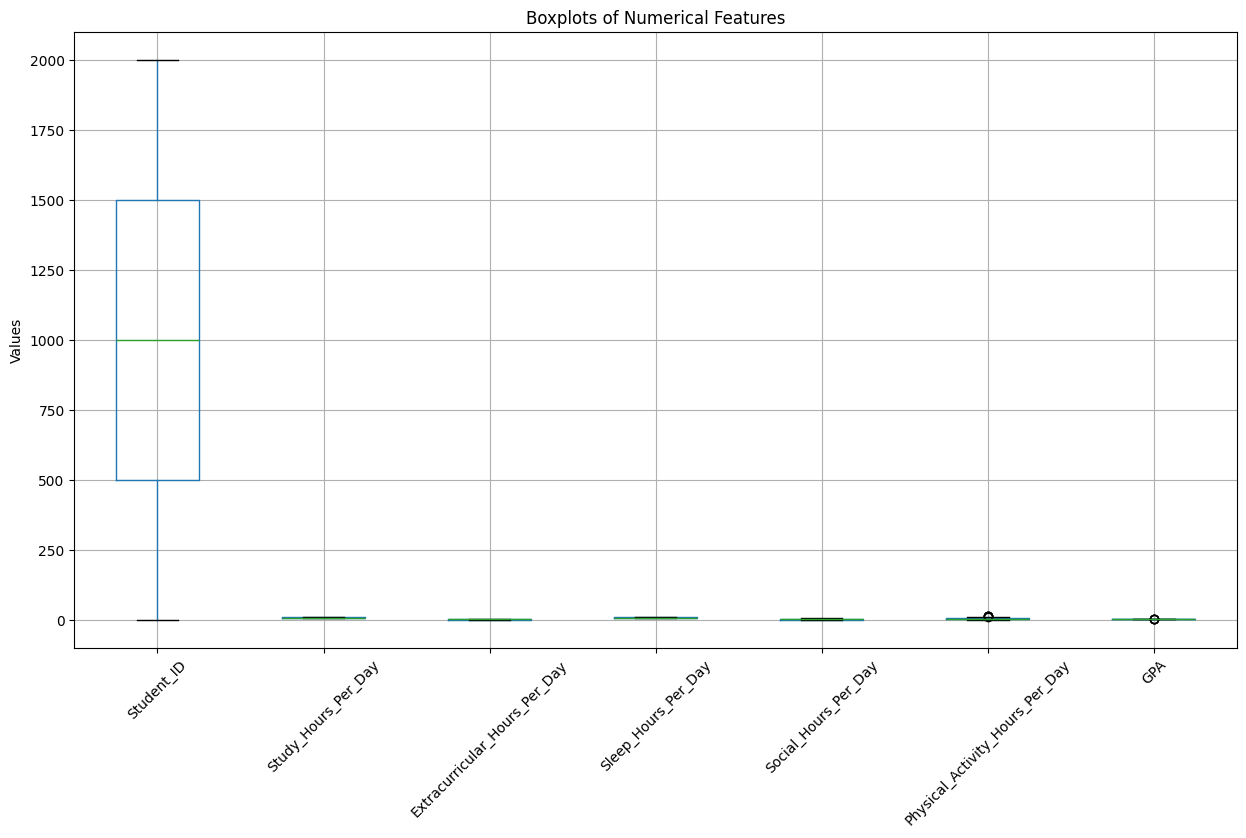

In [30]:
# Create boxplots for all numerical features
# Boxplots help us visually identify possible extreme values

plt.figure(figsize=(15, 8))

df[numerical_columns].boxplot()

# Rotate column names so they are easier to read
plt.xticks(rotation=45)

plt.title("Boxplots of Numerical Features")
plt.ylabel("Values")

plt.show()

In [31]:
# Create an empty dictionary to store the number of possible outliers
outlier_counts = {}

# Check every numerical column one by one
for column in numerical_columns:

    # Find the first quartile
    Q1 = df[column].quantile(0.25)

    # Find the third quartile
    Q3 = df[column].quantile(0.75)

    # Calculate the Interquartile Range
    IQR = Q3 - Q1

    # Calculate the lower boundary
    lower_limit = Q1 - 1.5 * IQR

    # Calculate the upper boundary
    upper_limit = Q3 + 1.5 * IQR

    # Find values outside the normal range
    outliers = (
        (df[column] < lower_limit) |
        (df[column] > upper_limit)
    )

    # Count the outliers
    outlier_counts[column] = outliers.sum()

# Convert the result into a table
outlier_summary = pd.DataFrame(
    outlier_counts.items(),
    columns=["Feature", "Possible Outliers"]
)

# Sort from highest to lowest
outlier_summary = outlier_summary.sort_values(
    by="Possible Outliers",
    ascending=False
)

# Display the result
outlier_summary

,Feature,Possible Outliers
5,Physical_Activity_Hours_Per_Day,5
6,GPA,4
0,Student_ID,0
2,Extracurricular_Hours_Per_Day,0
1,Study_Hours_Per_Day,0
4,Social_Hours_Per_Day,0
3,Sleep_Hours_Per_Day,0


In [32]:
# Display all columns again
# We will use this to identify the column we want our model to predict

print("All columns in the dataset:\n")

for column in df.columns:
    print("-", column)

All columns in the dataset:

- Student_ID
- Study_Hours_Per_Day
- Extracurricular_Hours_Per_Day
- Sleep_Hours_Per_Day
- Social_Hours_Per_Day
- Physical_Activity_Hours_Per_Day
- GPA
- Stress_Level


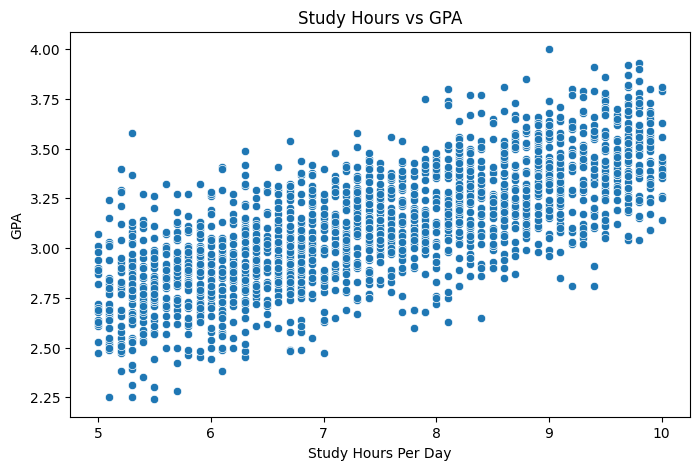

In [33]:
# Show how study hours are related to GPA
# Each point represents one student

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Study_Hours_Per_Day",
    y="GPA"
)

plt.title("Study Hours vs GPA")
plt.xlabel("Study Hours Per Day")
plt.ylabel("GPA")

plt.show()

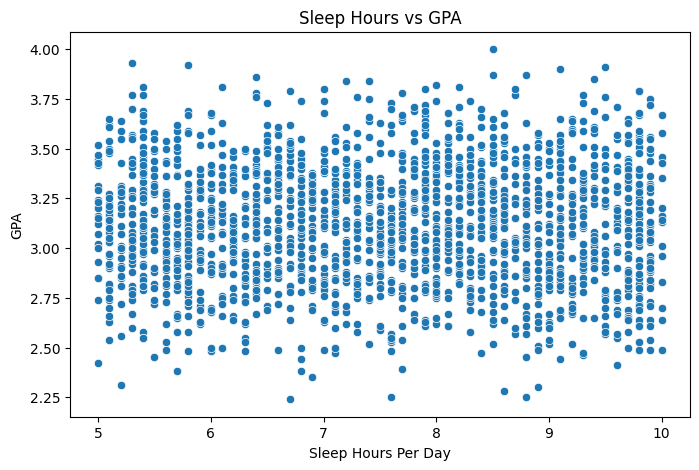

In [34]:
# Show the relationship between sleep and GPA

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Sleep_Hours_Per_Day",
    y="GPA"
)

plt.title("Sleep Hours vs GPA")
plt.xlabel("Sleep Hours Per Day")
plt.ylabel("GPA")

plt.show()

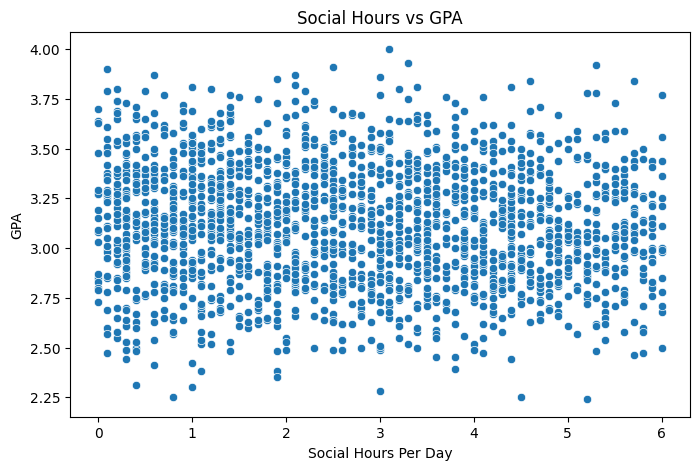

In [35]:
# Show the relationship between social activity and GPA

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Social_Hours_Per_Day",
    y="GPA"
)

plt.title("Social Hours vs GPA")
plt.xlabel("Social Hours Per Day")
plt.ylabel("GPA")

plt.show()

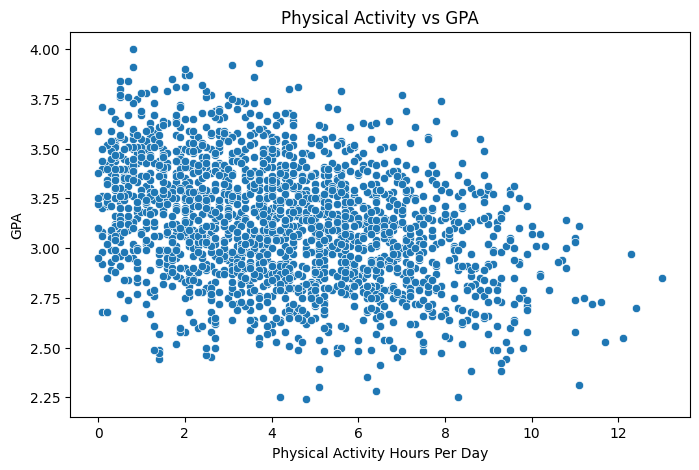

In [36]:
# Show the relationship between physical activity and GPA

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Physical_Activity_Hours_Per_Day",
    y="GPA"
)

plt.title("Physical Activity vs GPA")
plt.xlabel("Physical Activity Hours Per Day")
plt.ylabel("GPA")

plt.show()

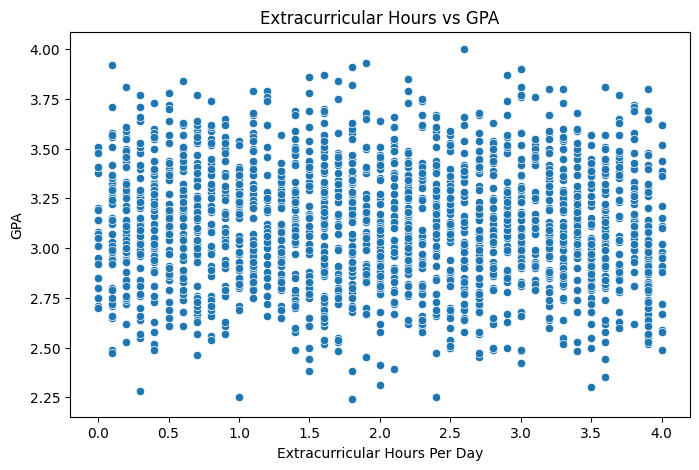

In [37]:
# Show the relationship between extracurricular activities and GPA

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Extracurricular_Hours_Per_Day",
    y="GPA"
)

plt.title("Extracurricular Hours vs GPA")
plt.xlabel("Extracurricular Hours Per Day")
plt.ylabel("GPA")

plt.show()

In [38]:
# Calculate the correlation of every numerical feature with GPA
# This helps us see which numerical factors are most related to GPA

gpa_correlation = (
    df[numerical_columns]
    .corr()["GPA"]
    .sort_values(ascending=False)
)

gpa_correlation

GPA                                1.000000
Study_Hours_Per_Day                0.734468
Student_ID                         0.005416
Sleep_Hours_Per_Day               -0.004278
Extracurricular_Hours_Per_Day     -0.032174
Social_Hours_Per_Day              -0.085677
Physical_Activity_Hours_Per_Day   -0.341152
Name: GPA, dtype: float64

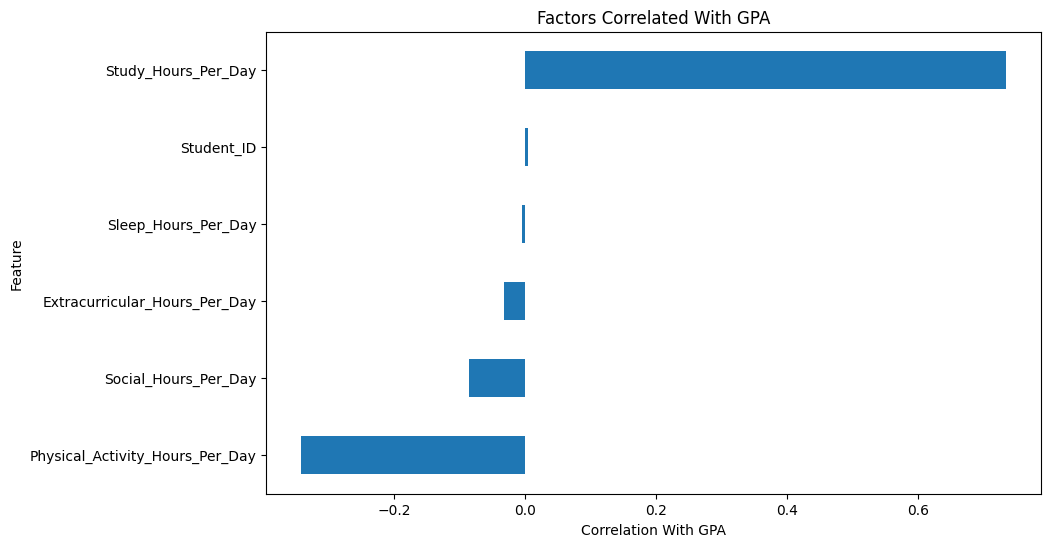

In [39]:
# Remove GPA itself from the chart
# We only want to see the relationship between GPA and other features

gpa_features = gpa_correlation.drop("GPA")

# Sort the correlations for a cleaner graph
gpa_features = gpa_features.sort_values()

# Create the graph
plt.figure(figsize=(10, 6))

gpa_features.plot(kind="barh")

plt.title("Factors Correlated With GPA")
plt.xlabel("Correlation With GPA")
plt.ylabel("Feature")

plt.show()

In [40]:
# Count how many students belong to each stress level

stress_counts = df["Stress_Level"].value_counts()

# Display the counts
stress_counts

Stress_Level
High        1029
Moderate     674
Low          297
Name: count, dtype: int64

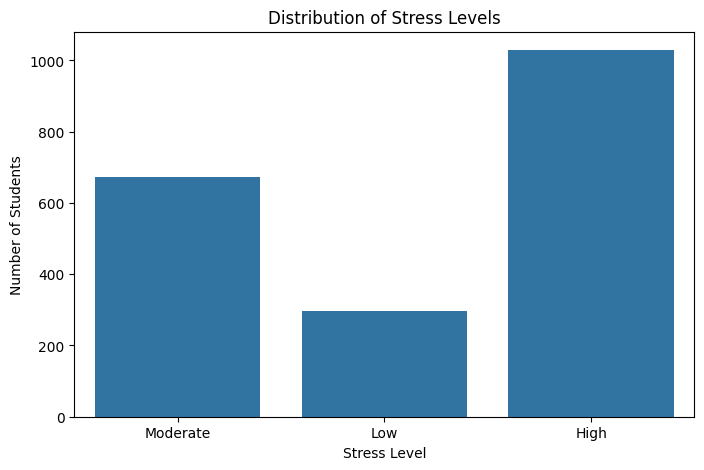

In [41]:
# Create a graph showing the number of students at each stress level

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Stress_Level"
)

plt.title("Distribution of Stress Levels")
plt.xlabel("Stress Level")
plt.ylabel("Number of Students")

plt.show()

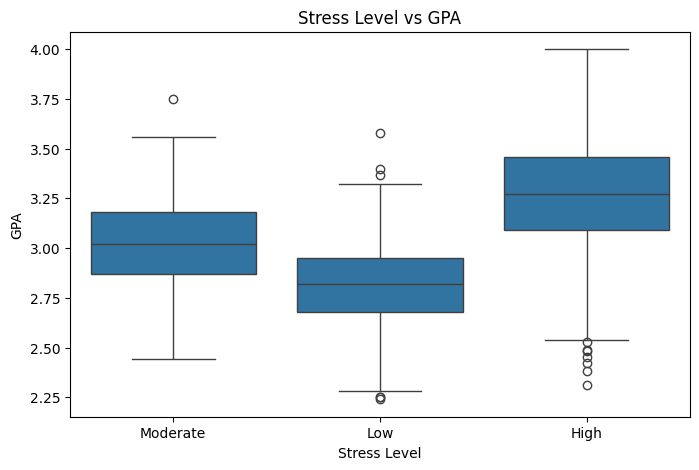

In [42]:
# Compare GPA across different stress levels

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Stress_Level",
    y="GPA"
)

plt.title("Stress Level vs GPA")
plt.xlabel("Stress Level")
plt.ylabel("GPA")

plt.show()

In [43]:
# Calculate the average GPA for each stress level

average_gpa_by_stress = (
    df.groupby("Stress_Level")["GPA"]
    .mean()
    .sort_values(ascending=False)
)

# Display the result
average_gpa_by_stress

Stress_Level
High        3.261973
Moderate    3.024837
Low         2.816869
Name: GPA, dtype: float64

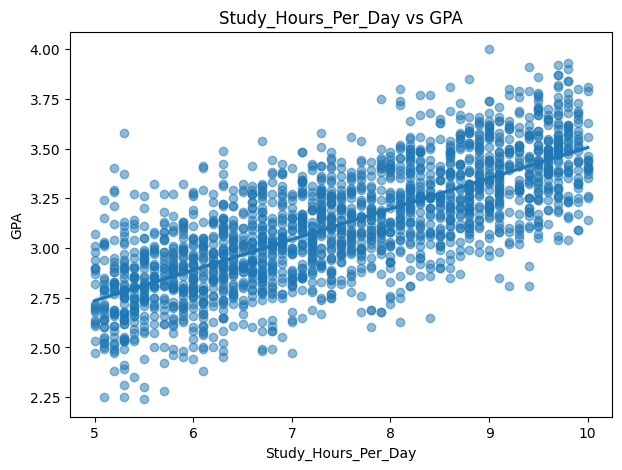

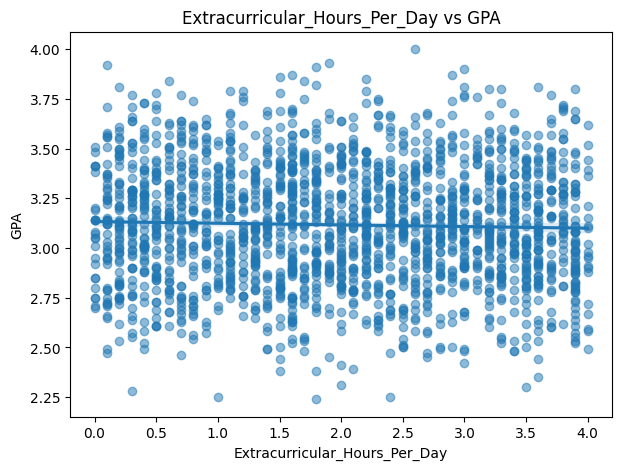

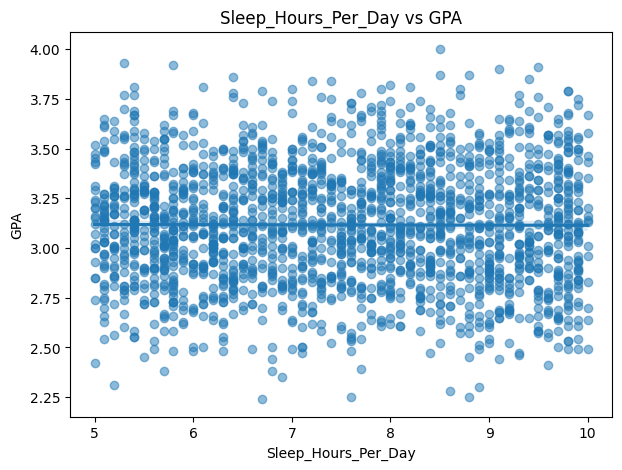

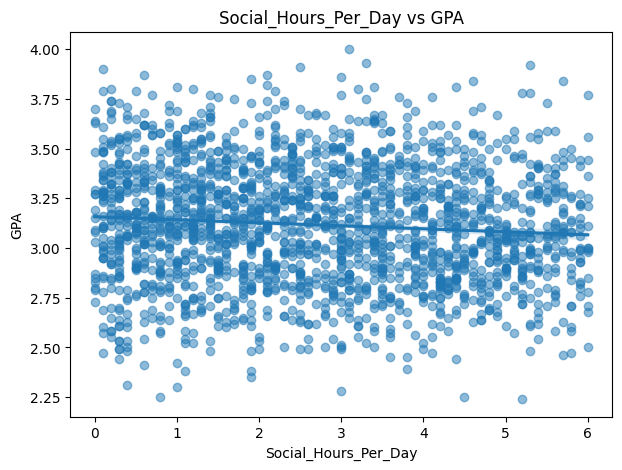

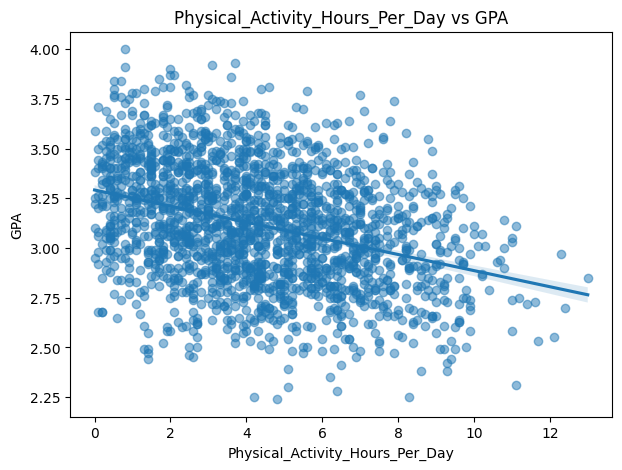

In [44]:
# Select numerical features that can be used to predict GPA
# Student_ID is removed because it is only an identifier

gpa_features = [
    "Study_Hours_Per_Day",
    "Extracurricular_Hours_Per_Day",
    "Sleep_Hours_Per_Day",
    "Social_Hours_Per_Day",
    "Physical_Activity_Hours_Per_Day"
]

# Create scatter plots for every feature
for feature in gpa_features:

    plt.figure(figsize=(7, 5))

    sns.regplot(
        data=df,
        x=feature,
        y="GPA",
        scatter_kws={"alpha": 0.5}
    )

    plt.title(f"{feature} vs GPA")
    plt.xlabel(feature)
    plt.ylabel("GPA")

    plt.show()

In [45]:
# Create a clean table showing the correlation of each feature with GPA

feature_correlation_table = pd.DataFrame({
    "Feature": gpa_features,
    "Correlation_With_GPA": [
        df[feature].corr(df["GPA"])
        for feature in gpa_features
    ]
})

# Sort by absolute correlation strength
feature_correlation_table["Absolute_Correlation"] = (
    feature_correlation_table["Correlation_With_GPA"].abs()
)

feature_correlation_table = feature_correlation_table.sort_values(
    by="Absolute_Correlation",
    ascending=False
)

# Display the final table
feature_correlation_table

,Feature,Correlation_With_GPA,Absolute_Correlation
0,Study_Hours_Per_Day,0.734468,0.734468
4,Physical_Activity_Hours_Per_Day,-0.341152,0.341152
3,Social_Hours_Per_Day,-0.085677,0.085677
1,Extracurricular_Hours_Per_Day,-0.032174,0.032174
2,Sleep_Hours_Per_Day,-0.004278,0.004278


In [46]:
# Add together the daily activity hours
# This helps us check whether the dataset contains unrealistic records

df["Total_Tracked_Hours"] = (
    df["Study_Hours_Per_Day"]
    + df["Extracurricular_Hours_Per_Day"]
    + df["Sleep_Hours_Per_Day"]
    + df["Social_Hours_Per_Day"]
    + df["Physical_Activity_Hours_Per_Day"]
)

# Show basic statistics of total tracked hours

df["Total_Tracked_Hours"].describe()

count    2.000000e+03
mean     2.400000e+01
std      1.575252e-15
min      2.400000e+01
25%      2.400000e+01
50%      2.400000e+01
75%      2.400000e+01
max      2.400000e+01
Name: Total_Tracked_Hours, dtype: float64

In [47]:
# Find students whose tracked activities exceed 24 hours
# A day cannot contain more than 24 hours

unrealistic_records = df[
    df["Total_Tracked_Hours"] > 24
]

# Show the number of unrealistic records
print(
    "Records with more than 24 tracked hours:",
    len(unrealistic_records)
)

Records with more than 24 tracked hours: 205


In [48]:
# Print the main information discovered during EDA

print("========== FOCUSGUARD EDA CONCLUSIONS ==========")

print("\nTarget:")
print("GPA")

print("\nNumber of students:")
print(len(df))

print("\nAverage GPA:")
print(round(df["GPA"].mean(), 2))

print("\nHighest GPA:")
print(df["GPA"].max())

print("\nLowest GPA:")
print(df["GPA"].min())

print("\nStrongest numerical relationships with GPA:")
print(feature_correlation_table)

print("\nAverage GPA by Stress Level:")
print(average_gpa_by_stress)

print("\nUnrealistic records (>24 tracked hours):")
print(len(unrealistic_records))

========== FOCUSGUARD EDA CONCLUSIONS ==========

Target:
GPA

Number of students:
2000

Average GPA:
3.12

Highest GPA:
4.0

Lowest GPA:
2.24

Strongest numerical relationships with GPA:
                           Feature  Correlation_With_GPA  Absolute_Correlation
0              Study_Hours_Per_Day              0.734468              0.734468
4  Physical_Activity_Hours_Per_Day             -0.341152              0.341152
3             Social_Hours_Per_Day             -0.085677              0.085677
1    Extracurricular_Hours_Per_Day             -0.032174              0.032174
2              Sleep_Hours_Per_Day             -0.004278              0.004278

Average GPA by Stress Level:
Stress_Level
High        3.261973
Moderate    3.024837
Low         2.816869
Name: GPA, dtype: float64

Unrealistic records (>24 tracked hours):
205


In [49]:
# Create a separate copy of the dataset
# This keeps our original dataframe safe

df_clean = df.copy()

# Check the shape of the clean working dataset
print("Clean dataset shape:", df_clean.shape)

Clean dataset shape: (2000, 9)


In [50]:
# Count duplicate rows before removing them
duplicates_before = df_clean.duplicated().sum()

print("Duplicate rows found:", duplicates_before)

# Remove completely duplicated rows
df_clean = df_clean.drop_duplicates()

# Show the new shape
print("Shape after removing duplicates:", df_clean.shape)

Duplicate rows found: 0
Shape after removing duplicates: (2000, 9)


In [51]:
# Count missing values in every column
# Missing values need to be handled before machine learning

missing_values = df_clean.isnull().sum()

# Display the result
missing_values

Student_ID                         0
Study_Hours_Per_Day                0
Extracurricular_Hours_Per_Day      0
Sleep_Hours_Per_Day                0
Social_Hours_Per_Day               0
Physical_Activity_Hours_Per_Day    0
GPA                                0
Stress_Level                       0
Total_Tracked_Hours                0
dtype: int64

In [52]:
# Check the minimum and maximum values of important numerical features
# This helps us find impossible values such as negative study hours

columns_to_check = [
    "Study_Hours_Per_Day",
    "Extracurricular_Hours_Per_Day",
    "Sleep_Hours_Per_Day",
    "Social_Hours_Per_Day",
    "Physical_Activity_Hours_Per_Day",
    "GPA"
]

# Display minimum and maximum values
df_clean[columns_to_check].agg(["min", "max"]).T

,min,max
Study_Hours_Per_Day,5.00,10.0
Extracurricular_Hours_Per_Day,0.00,4.0
Sleep_Hours_Per_Day,5.00,10.0
Social_Hours_Per_Day,0.00,6.0
Physical_Activity_Hours_Per_Day,0.00,13.0
GPA,2.24,4.0


In [53]:
# Check whether any important numerical feature contains negative values
# Hours and GPA should not be negative

for column in columns_to_check:

    negative_count = (df_clean[column] < 0).sum()

    print(column, "-> negative values:", negative_count)

Study_Hours_Per_Day -> negative values: 0
Extracurricular_Hours_Per_Day -> negative values: 0
Sleep_Hours_Per_Day -> negative values: 0
Social_Hours_Per_Day -> negative values: 0
Physical_Activity_Hours_Per_Day -> negative values: 0
GPA -> negative values: 0


In [54]:
# Display students whose GPA is outside the normal 0-10 range
# HIT uses a 10-point GPA scale, so these values would be suspicious

invalid_gpa = df_clean[
    (df_clean["GPA"] < 0) |
    (df_clean["GPA"] > 10)
]

print("Invalid GPA records:", len(invalid_gpa))

Invalid GPA records: 0


In [55]:
# Calculate the total number of tracked hours in one day
# A student cannot have more than 24 hours in a day

df_clean["Total_Tracked_Hours"] = (
    df_clean["Study_Hours_Per_Day"]
    + df_clean["Extracurricular_Hours_Per_Day"]
    + df_clean["Sleep_Hours_Per_Day"]
    + df_clean["Social_Hours_Per_Day"]
    + df_clean["Physical_Activity_Hours_Per_Day"]
)

# Show basic information about total tracked hours
df_clean["Total_Tracked_Hours"].describe()

count    2.000000e+03
mean     2.400000e+01
std      1.575252e-15
min      2.400000e+01
25%      2.400000e+01
50%      2.400000e+01
75%      2.400000e+01
max      2.400000e+01
Name: Total_Tracked_Hours, dtype: float64

In [56]:
# Find records where tracked activities exceed 24 hours
# These records need investigation because a day has only 24 hours

invalid_daily_hours = df_clean[
    df_clean["Total_Tracked_Hours"] > 24
]

print(
    "Records with more than 24 tracked hours:",
    len(invalid_daily_hours)
)

Records with more than 24 tracked hours: 205


In [57]:
# Display all unique stress levels
# This helps us understand the categorical feature

print("Stress levels:")
print(df_clean["Stress_Level"].unique())

print("\nNumber of students in each stress level:")
print(df_clean["Stress_Level"].value_counts())

Stress levels:
['Moderate' 'Low' 'High']

Number of students in each stress level:
Stress_Level
High        1029
Moderate     674
Low          297
Name: count, dtype: int64


In [58]:
# Calculate the total time spent on study and extracurricular activities
# These activities are directly related to academic routine

df_clean["Productive_Hours_Per_Day"] = (
    df_clean["Study_Hours_Per_Day"]
    + df_clean["Extracurricular_Hours_Per_Day"]
)

# Display the new feature
df_clean[
    [
        "Study_Hours_Per_Day",
        "Extracurricular_Hours_Per_Day",
        "Productive_Hours_Per_Day"
    ]
].head()

,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Productive_Hours_Per_Day
0,6.9,3.8,10.7
1,5.3,3.5,8.8
2,5.1,3.9,9.0
3,6.5,2.1,8.6
4,8.1,0.6,8.7


In [59]:
# Calculate approximate free time remaining in a 24-hour day
# We subtract all tracked activities from 24 hours

df_clean["Free_Time_Per_Day"] = (
    24 - df_clean["Total_Tracked_Hours"]
)

# Display the new feature
df_clean[
    [
        "Total_Tracked_Hours",
        "Free_Time_Per_Day"
    ]
].head()

,Total_Tracked_Hours,Free_Time_Per_Day
0,24.0,0.0
1,24.0,0.0
2,24.0,0.0
3,24.0,0.0
4,24.0,0.0


In [60]:
# Display statistics of our newly created features
# This helps us verify that the calculations make sense

df_clean[
    [
        "Productive_Hours_Per_Day",
        "Total_Tracked_Hours",
        "Free_Time_Per_Day"
    ]
].describe()

,Productive_Hours_Per_Day,Total_Tracked_Hours,Free_Time_Per_Day
count,2000.000000,2.000000e+03,2.000000e+03
mean,9.465900,2.400000e+01,-3.019807e-17
std,1.831613,1.575252e-15,1.574963e-15
min,5.100000,2.400000e+01,-3.552714e-15
25%,8.200000,2.400000e+01,0.000000e+00
50%,9.500000,2.400000e+01,0.000000e+00
75%,10.800000,2.400000e+01,0.000000e+00
max,13.800000,2.400000e+01,3.552714e-15


In [61]:
# Student_ID is only an identifier
# It does not represent a student's behaviour
# Therefore, we should not use it as an ML feature

df_model = df_clean.drop(
    columns=["Student_ID"]
)

# Check the remaining columns
df_model.columns

Index(['Study_Hours_Per_Day', 'Extracurricular_Hours_Per_Day',
       'Sleep_Hours_Per_Day', 'Social_Hours_Per_Day',
       'Physical_Activity_Hours_Per_Day', 'GPA', 'Stress_Level',
       'Total_Tracked_Hours', 'Productive_Hours_Per_Day', 'Free_Time_Per_Day'],
      dtype='object')

In [62]:
# Create X containing the input features
# GPA is removed because it is the value we want to predict

X = df_model.drop(
    columns=["GPA"]
)

# Create y containing only the target GPA
y = df_model["GPA"]

# Display the shapes
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2000, 9)
y shape: (2000,)


In [63]:
# Display the features that will be given to the ML model

print("Features used for prediction:")

for column in X.columns:
    print("-", column)

print("\nTarget:")
print("GPA")

Features used for prediction:
- Study_Hours_Per_Day
- Extracurricular_Hours_Per_Day
- Sleep_Hours_Per_Day
- Social_Hours_Per_Day
- Physical_Activity_Hours_Per_Day
- Stress_Level
- Total_Tracked_Hours
- Productive_Hours_Per_Day
- Free_Time_Per_Day

Target:
GPA


In [64]:
# Import the function used to split our dataset
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
# 80% is used for training
# 20% is kept for final testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Display the sizes
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1600
Testing samples: 400


In [65]:
# Display the first few rows of the training features
X_train.head()

,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,Stress_Level,Total_Tracked_Hours,Productive_Hours_Per_Day,Free_Time_Per_Day
968,9.7,3.7,7.5,1.0,2.1,High,24.0,13.4,0.000000e+00
240,6.3,3.2,6.6,2.7,5.2,Moderate,24.0,9.5,0.000000e+00
819,6.0,0.2,7.8,3.6,6.4,Moderate,24.0,6.2,0.000000e+00
692,7.8,3.4,9.0,0.7,3.1,Moderate,24.0,11.2,0.000000e+00
420,8.8,3.2,5.1,5.8,1.1,High,24.0,12.0,-3.552714e-15


In [66]:
# Display the first few rows of the testing features
X_test.head()

,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,Stress_Level,Total_Tracked_Hours,Productive_Hours_Per_Day,Free_Time_Per_Day
1860,6.2,4.0,6.0,3.5,4.3,Moderate,24.0,10.2,0.0
353,5.9,2.2,9.9,5.6,0.4,Low,24.0,8.1,0.0
1333,9.6,2.3,8.3,3.5,0.3,High,24.0,11.9,0.0
905,7.2,0.5,7.6,2.1,6.6,Moderate,24.0,7.7,0.0
1289,9.0,3.6,9.9,0.3,1.2,High,24.0,12.6,0.0


In [67]:
# Display some training GPA values
print("Training GPA values:")
print(y_train.head())

# Display some testing GPA values
print("\nTesting GPA values:")
print(y_test.head())

Training GPA values:
968    3.04
240    2.85
819    2.75
692    2.95
420    3.13
Name: GPA, dtype: float64

Testing GPA values:
1860    2.88
353     3.12
1333    3.41
905     3.11
1289    3.19
Name: GPA, dtype: float64


In [68]:
# Identify numerical features
# These features already contain numbers

numeric_features = X.select_dtypes(
    include=np.number
).columns

# Identify categorical features
# These features contain categories/text

categorical_features = X.select_dtypes(
    include="object"
).columns

# Display both groups
print("Numerical features:")
print(list(numeric_features))

print("\nCategorical features:")
print(list(categorical_features))

Numerical features:
['Study_Hours_Per_Day', 'Extracurricular_Hours_Per_Day', 'Sleep_Hours_Per_Day', 'Social_Hours_Per_Day', 'Physical_Activity_Hours_Per_Day', 'Total_Tracked_Hours', 'Productive_Hours_Per_Day', 'Free_Time_Per_Day']

Categorical features:
['Stress_Level']


In [69]:
# Import tools needed for preprocessing

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Create a transformer for numerical and categorical columns
# Numerical columns are kept as they are
# Categorical columns are converted into numerical values

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ],
    remainder="passthrough"
)

# Display the preprocessing object
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. 

In [70]:
# Learn the categorical encoding from the training data
# We use only training data to avoid data leakage

X_train_processed = preprocessor.fit_transform(X_train)

# Apply the same transformation to test data
X_test_processed = preprocessor.transform(X_test)

# Display the shapes
print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (1600, 11)
Processed testing shape: (400, 11)


In [71]:
# Check that our training and testing data are ready for machine learning

print("========== ML READY DATA ==========")

print("\nTraining features:", X_train_processed.shape)
print("Testing features:", X_test_processed.shape)

print("\nTraining target:", y_train.shape)
print("Testing target:", y_test.shape)

print("\nTarget: GPA")

print("\nMachine learning data preparation completed successfully.")

========== ML READY DATA ==========

Training features: (1600, 11)
Testing features: (400, 11)

Training target: (1600,)
Testing target: (400,)

Target: GPA

Machine learning data preparation completed successfully.


In [72]:
# Import Linear Regression
# This will be our simple baseline model

from sklearn.linear_model import LinearRegression

# Import Random Forest
# This can learn more complex relationships

from sklearn.ensemble import RandomForestRegressor

# Import Gradient Boosting
# This is another powerful model for tabular data

from sklearn.ensemble import GradientBoostingRegressor

# Import evaluation metrics
# These metrics tell us how well our models perform

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# Import Pipeline
# Pipeline connects preprocessing and machine learning together

from sklearn.pipeline import Pipeline

In [73]:
# Create a simple Linear Regression model
# This will be our baseline model

linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

# Train the model using only training data

linear_model.fit(X_train, y_train)

print("Linear Regression training completed.")

Linear Regression training completed.


In [74]:
# Use the trained Linear Regression model
# to predict GPA for students in the test dataset

linear_predictions = linear_model.predict(X_test)

# Show the first 10 predictions

print("First 10 predicted GPAs:")
print(linear_predictions[:10])

First 10 predicted GPAs:
[2.88809233 2.88248664 3.44208737 3.07174599 3.33234134 3.14520481
 3.30288013 3.10357924 3.00813378 3.35127599]


In [75]:
# Calculate Mean Absolute Error
# Lower MAE means better predictions

linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

# Calculate Root Mean Squared Error
# Lower RMSE means better predictions

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

# Calculate R-squared
# Higher R² generally means the model explains more variation

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

# Display the results

print("===== Linear Regression =====")
print("MAE :", round(linear_mae, 4))
print("RMSE:", round(linear_rmse, 4))
print("R²  :", round(linear_r2, 4))

===== Linear Regression =====
MAE : 0.1644
RMSE: 0.2056
R²  : 0.5474


In [76]:
# Create a Random Forest regression model
# Random Forest can learn non-linear relationships

random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        max_depth=None,
        min_samples_split=2,
        n_jobs=-1
    ))
])

# Train the Random Forest model

random_forest_model.fit(
    X_train,
    y_train
)

print("Random Forest training completed.")

Random Forest training completed.


In [77]:
# Predict GPA using the Random Forest model

rf_predictions = random_forest_model.predict(X_test)

# Display the first 10 predictions

print("First 10 predicted GPAs:")
print(rf_predictions[:10])

First 10 predicted GPAs:
[2.9175     2.92633333 3.4429     3.08096667 3.4246     3.0814
 3.62233333 3.0806     3.11       3.45316667]


In [78]:
# Calculate MAE

rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

# Calculate RMSE

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

# Calculate R²

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

# Display the results

print("===== Random Forest =====")
print("MAE :", round(rf_mae, 4))
print("RMSE:", round(rf_rmse, 4))
print("R²  :", round(rf_r2, 4))

===== Random Forest =====
MAE : 0.1818
RMSE: 0.226
R²  : 0.4531


In [79]:
# Create a Gradient Boosting regression model
# It builds many small models one after another
# to improve prediction accuracy

gradient_model = Pipeline([
    ("preprocessor", preprocessor),
    
    ("model", GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

# Train the Gradient Boosting model

gradient_model.fit(
    X_train,
    y_train
)

print("Gradient Boosting training completed.")

Gradient Boosting training completed.


In [80]:
# Predict GPA using Gradient Boosting

gradient_predictions = gradient_model.predict(X_test)

# Display the first 10 predictions

print("First 10 predicted GPAs:")
print(gradient_predictions[:10])

First 10 predicted GPAs:
[2.8639902  2.94601199 3.44870978 3.06981672 3.42225702 3.13316892
 3.37286325 3.13275321 3.01541774 3.41247542]


In [81]:
# Calculate MAE

gradient_mae = mean_absolute_error(
    y_test,
    gradient_predictions
)

# Calculate RMSE

gradient_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        gradient_predictions
    )
)

# Calculate R²

gradient_r2 = r2_score(
    y_test,
    gradient_predictions
)

# Display the results

print("===== Gradient Boosting =====")
print("MAE :", round(gradient_mae, 4))
print("RMSE:", round(gradient_rmse, 4))
print("R²  :", round(gradient_r2, 4))

===== Gradient Boosting =====
MAE : 0.1701
RMSE: 0.2123
R²  : 0.5172


In [82]:
# Create a table containing the performance of all models

model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    
    "MAE": [
        linear_mae,
        rf_mae,
        gradient_mae
    ],
    
    "RMSE": [
        linear_rmse,
        rf_rmse,
        gradient_rmse
    ],
    
    "R2": [
        linear_r2,
        rf_r2,
        gradient_r2
    ]
})

# Sort models by RMSE
# Lower RMSE is better

model_results = model_results.sort_values(
    by="RMSE"
).reset_index(drop=True)

# Display the comparison

model_results

,Model,MAE,RMSE,R2
0,Linear Regression,0.164361,0.205571,0.547365
1,Gradient Boosting,0.170142,0.212320,0.517156
2,Random Forest,0.181824,0.225969,0.453082


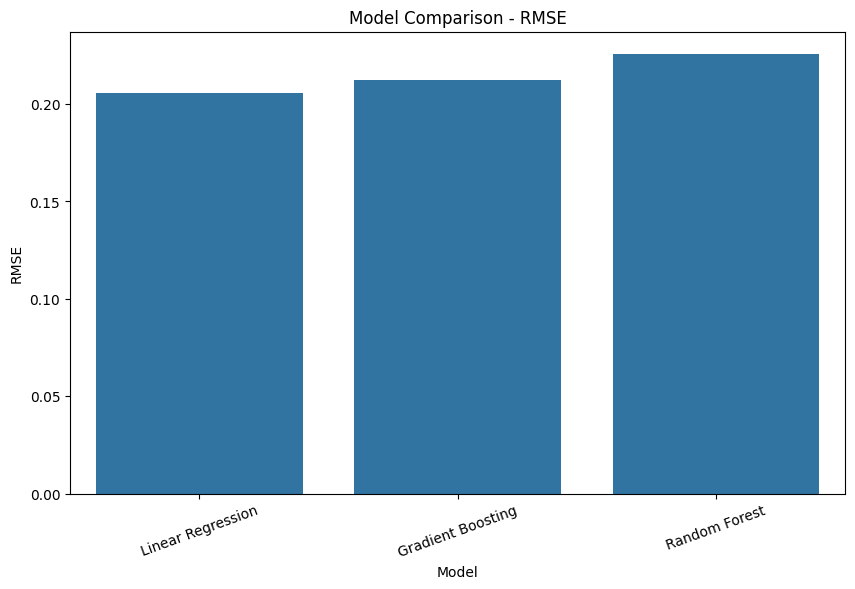

In [83]:
# Create a graph to compare model RMSE values

plt.figure(figsize=(10, 6))

sns.barplot(
    data=model_results,
    x="Model",
    y="RMSE"
)

plt.title("Model Comparison - RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.xticks(rotation=20)

plt.show()

In [84]:
# Select the model with the lowest RMSE

best_model_name = model_results.loc[
    0,
    "Model"
]

# Print the winning model

print("Best model:", best_model_name)

Best model: Linear Regression


In [85]:
# Select the trained model based on the model comparison

if best_model_name == "Linear Regression":
    
    best_model = linear_model

elif best_model_name == "Random Forest":
    
    best_model = random_forest_model

else:
    
    best_model = gradient_model

# Confirm the selected model

print("Selected model:", best_model_name)

Selected model: Linear Regression


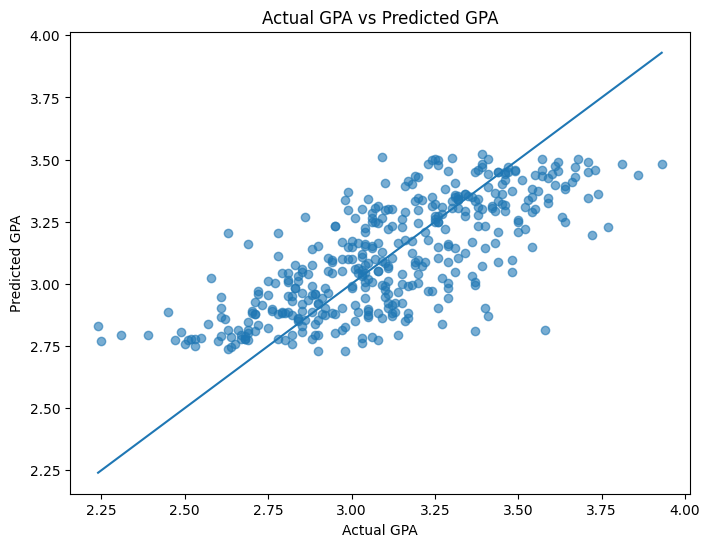

In [86]:
# Generate predictions using our best model

best_predictions = best_model.predict(X_test)

# Create the graph

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.6
)

# Create a perfect-prediction reference line

minimum = min(y_test.min(), best_predictions.min())
maximum = max(y_test.max(), best_predictions.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum]
)

plt.title("Actual GPA vs Predicted GPA")
plt.xlabel("Actual GPA")
plt.ylabel("Predicted GPA")

plt.show()

In [87]:
# Calculate prediction errors
# Error = Actual GPA - Predicted GPA

prediction_errors = y_test - best_predictions

# Display basic statistics of the errors

prediction_errors.describe()

count    400.000000
mean       0.002662
std        0.205811
min       -0.591348
25%       -0.142433
50%       -0.009658
75%        0.151159
max        0.765844
Name: GPA, dtype: float64

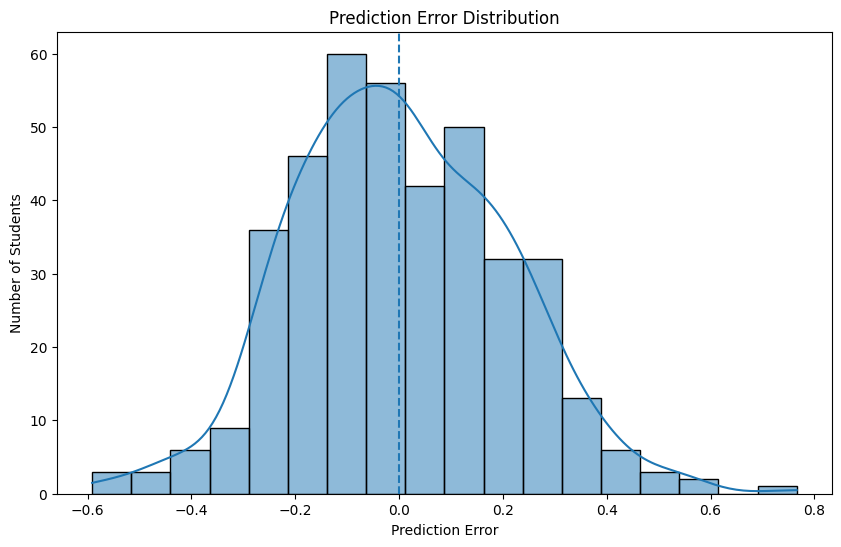

In [88]:
# Plot the distribution of prediction errors
# Ideally, errors should be reasonably centered around zero

plt.figure(figsize=(10, 6))

sns.histplot(
    prediction_errors,
    kde=True
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title("Prediction Error Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Number of Students")

plt.show()

In [89]:
# Create a table comparing actual GPA with predicted GPA

prediction_table = pd.DataFrame({
    "Actual_GPA": y_test.values,
    "Predicted_GPA": best_predictions
})

# Calculate the absolute error

prediction_table["Absolute_Error"] = (
    prediction_table["Actual_GPA"]
    - prediction_table["Predicted_GPA"]
).abs()

# Display the first 15 predictions

prediction_table.head(15)

,Actual_GPA,Predicted_GPA,Absolute_Error
0,2.88,2.888092,0.008092
1,3.12,2.882487,0.237513
2,3.41,3.442087,0.032087
3,3.11,3.071746,0.038254
4,3.19,3.332341,0.142341
5,3.31,3.145205,0.164795
6,3.03,3.302880,0.272880
7,3.12,3.103579,0.016421
8,3.06,3.008134,0.051866
9,3.36,3.351276,0.008724


In [90]:
# Sort predictions by the largest error
# This helps us find students our model struggled to predict

largest_errors = prediction_table.sort_values(
    by="Absolute_Error",
    ascending=False
)

# Display the 10 largest errors

largest_errors.head(10)

,Actual_GPA,Predicted_GPA,Absolute_Error
214,3.58,2.814156,0.765844
385,2.24,2.831348,0.591348
253,2.63,3.205084,0.575084
77,3.37,2.810337,0.559663
337,3.77,3.227238,0.542762
103,3.41,2.871281,0.538719
306,3.72,3.198377,0.521623
361,2.25,2.771479,0.521479
228,3.40,2.903337,0.496663
115,2.31,2.793771,0.483771


In [91]:
# Import joblib for saving machine learning models

import joblib

# Save the complete best model pipeline

joblib.dump(
    best_model,
    "focusguard_gpa_model.pkl"
)

print("Best model saved successfully!")
print("File: focusguard_gpa_model.pkl")

Best model saved successfully!
File: focusguard_gpa_model.pkl


In [92]:
# Load the saved model back into Python
# This checks that our saved model works correctly

loaded_model = joblib.load(
    "focusguard_gpa_model.pkl"
)

# Make predictions using the loaded model

loaded_predictions = loaded_model.predict(
    X_test
)

# Check whether the predictions are the same
# as the original best model

print(
    "Predictions match:",
    np.allclose(
        best_predictions,
        loaded_predictions
    )
)

Predictions match: True


In [93]:
# Print the final machine learning results

print("======================================")
print("       FOCUSGUARD ML REPORT")
print("======================================")

print("\nBest Model:")
print(best_model_name)

print("\nMAE:")
print(round(
    model_results.loc[0, "MAE"],
    4
))

print("\nRMSE:")
print(round(
    model_results.loc[0, "RMSE"],
    4
))

print("\nR² Score:")
print(round(
    model_results.loc[0, "R2"],
    4
))

print("\nTraining Samples:")
print(len(X_train))

print("\nTesting Samples:")
print(len(X_test))

print("\nModel File:")
print("focusguard_gpa_model.pkl")

print("\n======================================")
print("       MACHINE LEARNING COMPLETE")
print("======================================")


       FOCUSGUARD ML REPORT

Best Model:
Linear Regression

MAE:
0.1644

RMSE:
0.2056

R² Score:
0.5474

Training Samples:
1600

Testing Samples:
400

Model File:
focusguard_gpa_model.pkl

       MACHINE LEARNING COMPLETE


In [94]:
# Save important information about our trained model
# This information will be used inside the Streamlit dashboard

import json

model_information = {
    "model_name": best_model_name,
    "mae": float(model_results.loc[0, "MAE"]),
    "rmse": float(model_results.loc[0, "RMSE"]),
    "r2": float(model_results.loc[0, "R2"]),
    "training_samples": int(len(X_train)),
    "testing_samples": int(len(X_test)),
    "target": "GPA"
}

# Save the information as a JSON file

with open("model_info.json", "w") as file:
    json.dump(model_information, file, indent=4)

print("Model information saved successfully!")

Model information saved successfully!
